# 02 · Dimensionality reduction & clustering
**Input:** `data/processed/adata_processed.h5ad`
**Output:** `data/processed/adata_clustered.h5ad`

Covers: PCA, neighbor graph, UMAP, Leiden clustering at multiple resolutions.


In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
adata = sc.read("../data/processed/adata_processed.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 2795 × 33694
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'sample_colors'
    layers: 'counts', 'logcounts'


## PCA

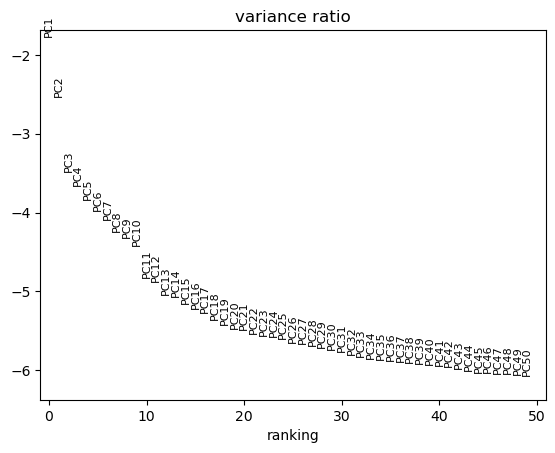

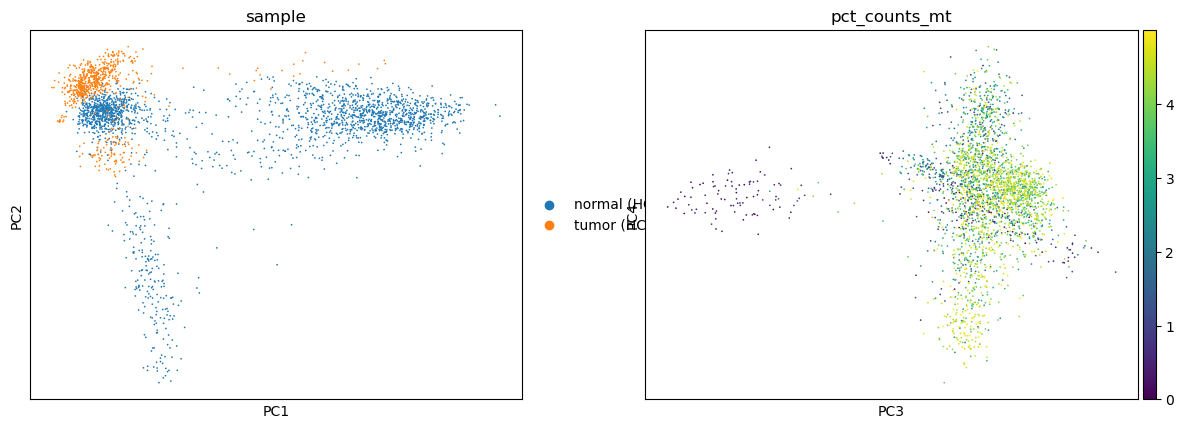

In [3]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
sc.pl.pca(adata, color=["sample","pct_counts_mt"],
          dimensions=[(0,1),(2,3)], size=6)

## Neighbor graph & UMAP

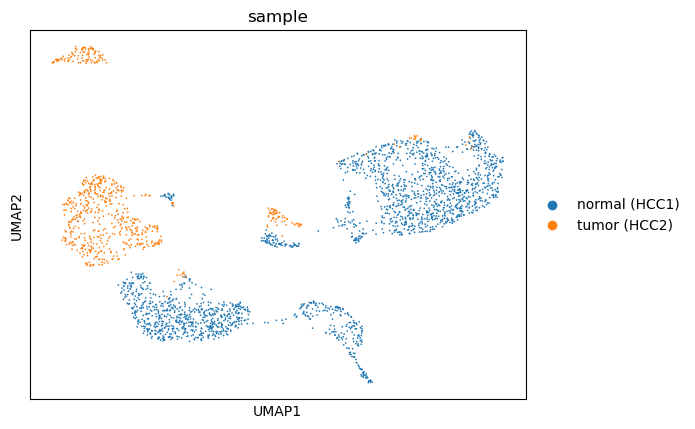

In [5]:
def dim_red(adata, n_neighbors=15, n_pcs=10):
    sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs)
    sc.tl.umap(adata)
    return adata

adata = dim_red(adata)
sc.pl.umap(adata, color="sample", size=6)

## Leiden clustering at multiple resolutions

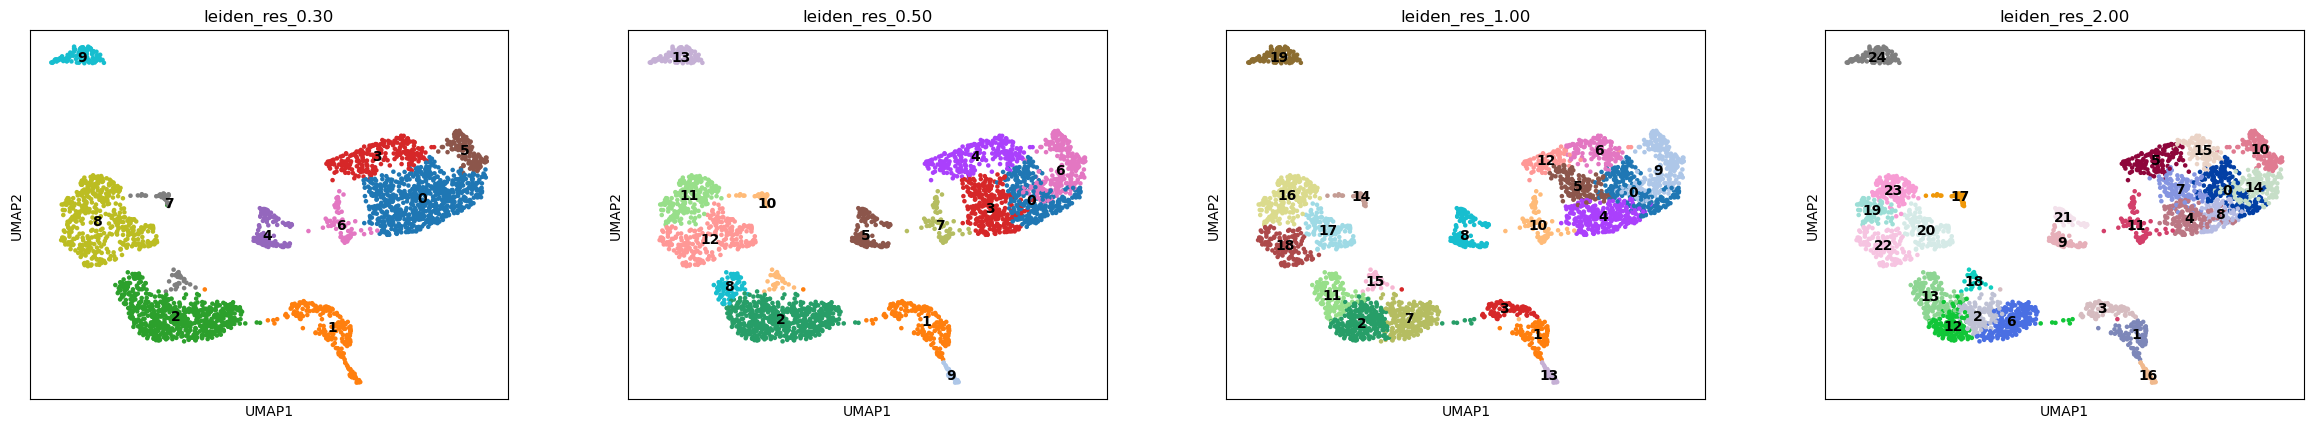

In [6]:
for res in [0.3, 0.5, 1.0, 2.0]:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:.2f}",
                 resolution=res, flavor="igraph")

sc.pl.umap(adata,
           color=["leiden_res_0.30","leiden_res_0.50",
                  "leiden_res_1.00","leiden_res_2.00"],
           legend_loc="on data")

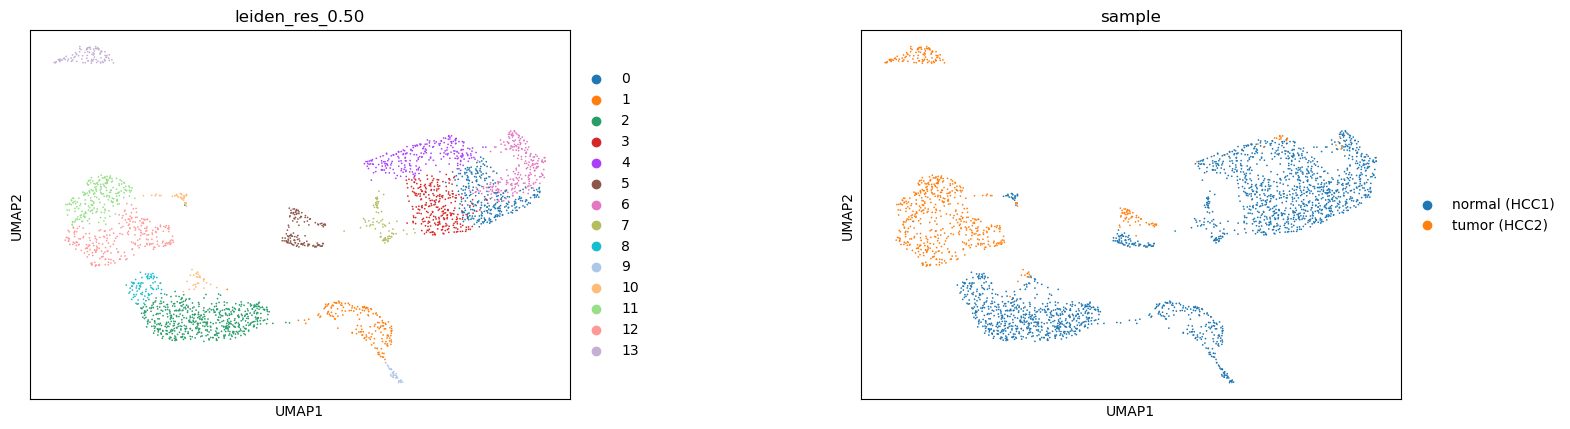

In [7]:
sc.pl.umap(adata, color=["leiden_res_0.50","sample"],
           wspace=0.4, size=6)

In [8]:
adata.write("../data/processed/adata_clustered.h5ad")
print("Saved: adata_clustered.h5ad")

Saved: adata_clustered.h5ad
